In [1]:
import geopandas as gpd
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [6]:
DATA = Path("../data/raw/geology/NGMDB_GeMS_3758/GeMS_shapefiles")

MAPUNIT_POLYS = DATA / "MapUnitPolys.shp"
DMU = DATA / "DescriptionOfMapUnits.csv"

In [7]:
polys = gpd.read_file(MAPUNIT_POLYS)

print(polys.columns)
polys.head()

Index(['OBJECTID', 'MapUnit', 'Label', 'Symbol', 'geometry'], dtype='str')


,OBJECTID,MapUnit,Label,Symbol,geometry
0,1,Qalt,Qalt,50,"POLYGON ((762810.516 823632.711, 762918.738 82..."
1,2,Qalt,Qalt,50,"POLYGON ((756938.927 826193.62, 757064.581 825..."
2,3,Qalt,Qalt,50,"POLYGON ((756683.743 829732.109, 756797.896 82..."
3,4,Qalt,Qalt,50,"POLYGON ((756222.002 830095.669, 756270.758 83..."
4,5,Qalt,Qalt,50,"POLYGON ((756234.94 831578.792, 756441.359 831..."


In [8]:
dmu = pd.read_csv(DMU)

print(dmu.columns)
dmu.head()

Index(['OBJECTID', 'MapUnit', 'Name', 'FullName', 'Age', 'Description',
       'HierarchyKey', 'ParagraphStyle', 'Label', 'Symbol', 'AreaFillRGB',
       'AreaFillPatternDescription', 'DescriptionSourceID', 'GeoMaterial',
       'GeoMaterialConfidence', 'DescriptionOfMapUnits_ID'],
      dtype='str')


,OBJECTID,MapUnit,Name,FullName,Age,Description,HierarchyKey,ParagraphStyle,Label,Symbol,AreaFillRGB,AreaFillPatternDescription,DescriptionSourceID,GeoMaterial,GeoMaterialConfidence,DescriptionOfMapUnits_ID
0,1,water,Water,Water,Modern,Water,01,DMUUnit1,water,300.0,"204,255,255",NaN,OsborneOthers1989,Water or ice,High,DMU1
1,2,NaN,Quaternary System,Quaternary,Quaternary,NaN,02,DMUHeading2,NaN,NaN,NaN,NaN,OsborneOthers1989,NaN,NaN,DMU2
2,3,Qalt,"Alluvial, coastal, and low terrace deposits","Alluvial, coastal, and low terrace deposits",Holocene,Varicolored fine to coarse quartz sand contain...,02-01,DMUUnit1,Qalt,50.0,"255,255,153",NaN,OsborneOthers1989,Alluvial sediment,High,DMU3
3,4,Qt,High terrace deposits,High terrace deposits,Pleistocene,Varicolored lenticular beds a poorly sorted sa...,02-02,DMUUnit1,Qt,195.0,"235,153,000",NaN,OsborneOthers1989,Sand and gravel of unspecified origin,High,DMU4
4,5,NaN,Coastal Plain,Coastal Plain,NaN,NaN,03,DMUHeading2,NaN,NaN,NaN,NaN,OsborneOthers1989,NaN,NaN,DMU5


In [9]:
polys = polys.merge(
    dmu,
    on="MapUnit",
    how="left"
)

In [21]:
polys[["MapUnit", "Name","Description"]].head(20)

,MapUnit,Name,Description
0,Qalt,"Alluvial, coastal, and low terrace deposits",Varicolored fine to coarse quartz sand contain...
1,Qalt,"Alluvial, coastal, and low terrace deposits",Varicolored fine to coarse quartz sand contain...
2,Qalt,"Alluvial, coastal, and low terrace deposits",Varicolored fine to coarse quartz sand contain...
3,Qalt,"Alluvial, coastal, and low terrace deposits",Varicolored fine to coarse quartz sand contain...
4,Qalt,"Alluvial, coastal, and low terrace deposits",Varicolored fine to coarse quartz sand contain...
5,Qalt,"Alluvial, coastal, and low terrace deposits",Varicolored fine to coarse quartz sand contain...
6,water,Water,Water
7,Qalt,"Alluvial, coastal, and low terrace deposits",Varicolored fine to coarse quartz sand contain...
8,water,Water,Water
9,water,Water,Water


In [20]:
polys.columns

Index(['OBJECTID_x', 'MapUnit', 'Label_x', 'Symbol_x', 'geometry',
       'OBJECTID_y', 'Name', 'FullName', 'Age', 'Description', 'HierarchyKey',
       'ParagraphStyle', 'Label_y', 'Symbol_y', 'AreaFillRGB',
       'AreaFillPatternDescription', 'DescriptionSourceID', 'GeoMaterial',
       'GeoMaterialConfidence', 'DescriptionOfMapUnits_ID'],
      dtype='str')

In [12]:
[name for name in polys["Name"].dropna().unique() if "Chalk" in name]

['Prairie Bluff Chalk', 'Demopolis Chalk', 'Mooreville Chalk']

In [15]:
selma = polys[
    polys["Name"].str.contains("Chalk", case=False, na=False)
].copy()

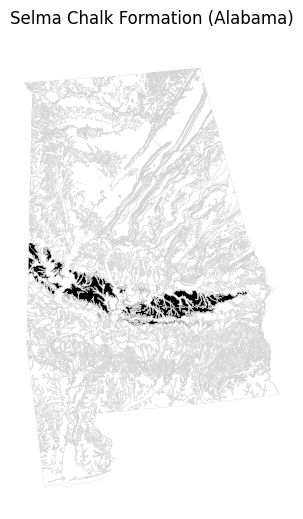

In [16]:
fig, ax = plt.subplots(figsize=(8,6))

polys.boundary.plot(ax=ax, color="lightgray", linewidth=0.2)

selma.plot(
    ax=ax,
    color="black"
)

ax.set_title("Selma Chalk Formation (Alabama)")
ax.set_axis_off()

plt.show()

In [17]:
selma_clean = selma[[
    "MapUnit",
    "Name",
    "Age",
    "geometry"
]].copy()

In [19]:
selma_clean.to_file(
    "../data/processed/selma_chalk_alabama.geojson",
    driver="GeoJSON"
)

In [22]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [29]:
MS_SHP = Path("../data/raw/geology/MS_Geology_1969/MS_Geology_1969.shp")

In [30]:
ms = gpd.read_file(MS_SHP)

print(ms.shape)
print(ms.columns.tolist())
ms.head()

(893, 10)
['AREA', 'PERIMETER', 'GEO_', 'GEO_ID', 'FORMATION', 'Econ_Min', 'AGE', 'LITHOLOGY', 'GEO_SYMBOL', 'geometry']


,AREA,PERIMETER,GEO_,GEO_ID,FORMATION,Econ_Min,AGE,LITHOLOGY,GEO_SYMBOL,geometry
0,0.0,0.0,2,1,CITRONELLE,Gravel-Bearing Strata,PLEISTOCENE,"Sand, gravel, and clay",Pc,"POLYGON ((523257.219 1264981.466, 523115.281 1..."
1,0.0,0.0,3,2,CITRONELLE,Gravel-Bearing Strata,PLEISTOCENE,"Sand, gravel, and clay",Pc,"POLYGON ((522942.526 1259256.046, 522646.545 1..."
2,0.0,0.0,4,3,CITRONELLE,Gravel-Bearing Strata,PLEISTOCENE,"Sand, gravel, and clay",Pc,"POLYGON ((506409.906 1265857.997, 506076.537 1..."
3,0.0,0.0,5,4,CITRONELLE,Gravel-Bearing Strata,PLEISTOCENE,"Sand, gravel, and clay",Pc,"POLYGON ((491830.129 1269875.165, 491727.913 1..."
4,0.0,0.0,6,5,CITRONELLE,Gravel-Bearing Strata,PLEISTOCENE,"Sand, gravel, and clay",Pc,"POLYGON ((491556.114 1242657.669, 491703.477 1..."


In [31]:
for col in ms.columns:
    if ms[col].dtype == "object":
        print(f"\n=== {col} ===")
        print(ms[col].dropna().astype(str).head(20).tolist())

In [34]:
for col in ["Econ_min", "FORMATION", "NAME", "LABEL", "SYMBOL"]:
    if col in ms.columns:
        print(f"\n=== unique values in {col} ===")
        vals = sorted(ms[col].dropna().astype(str).unique())
        print(vals[:100])


=== unique values in FORMATION ===
['ARCOLA LIMESTONE', 'BASHI', 'CATAHOULA', 'CHATTANOOGA SHALE', 'CHESTER GROUP', 'CITRONELLE', 'CLAYTON', 'COASTAL DEPOSITS', 'COCKFIELD', 'COFFEE SAND', 'COOK MOUNTAIN', 'DEMOPOLIS CHALK', 'EUTAW', 'FOREST HILL/RED BLUFF', 'JACKSON GROUP', 'KOSCIUSKO', 'MCNAIRY SAND', 'MERAMEC OSAGE KINDERHOOK', 'MID NANAFALIA', 'MOOREVILLE CHALK', 'MS RIVER ALLUVIUM', 'NAHEOLA', 'PASCAGOULA/HATTIESBURG', 'PORTERS CREEK', 'PRAIRIE BLUFF/OWL CREEK', 'RIPLEY', 'TALLAHATTA', 'TOMBIGBEE SAND', 'TUSCALOOSA', 'VICKSBURG/CHICKASAWHAY', 'WILCOX', 'ZILPHA/WINONA']


In [35]:
unit_col = "FORMATION"   # replace with the correct column name

keywords = ["chalk", "mooreville", "demopolis", "prairie", "selma"]

for kw in keywords:
    matches = sorted(
        [x for x in ms[unit_col].dropna().astype(str).unique() if kw.lower() in x.lower()]
    )
    print(f"\n--- {kw} ---")
    print(matches)


--- chalk ---
['DEMOPOLIS CHALK', 'MOOREVILLE CHALK']

--- mooreville ---
['MOOREVILLE CHALK']

--- demopolis ---
['DEMOPOLIS CHALK']

--- prairie ---
['PRAIRIE BLUFF/OWL CREEK']

--- selma ---
[]


In [36]:
pattern = r"chalk|mooreville|demopolis|prairie bluff|selma"

ms_black_belt = ms[
    ms[unit_col].astype(str).str.contains(pattern, case=False, na=False)
].copy()

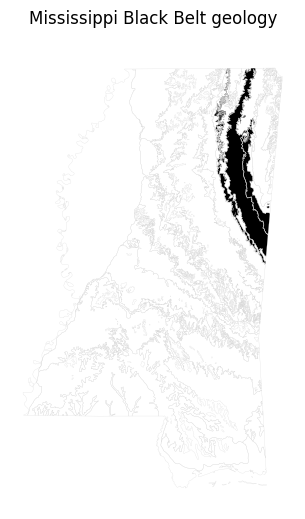

In [37]:
fig, ax = plt.subplots(figsize=(8, 6))

ms.boundary.plot(ax=ax, color="lightgray", linewidth=0.15)
ms_black_belt.plot(ax=ax, color="black")

ax.set_title("Mississippi Black Belt geology")
ax.set_axis_off()
plt.show()

In [38]:
OUT = Path("../data/processed")
OUT.mkdir(parents=True, exist_ok=True)

keep_cols = [unit_col, "geometry"]
ms_black_belt_clean = ms_black_belt[keep_cols].copy()

ms_black_belt_clean.to_file(
    OUT / "mississippi_black_belt_geology.geojson",
    driver="GeoJSON"
)

In [41]:
COMMON_CRS = "EPSG:5070"  # NAD83 / Conus Albers

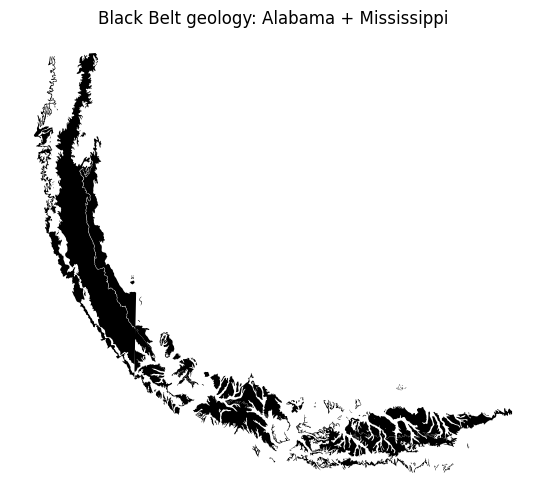

In [42]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

COMMON_CRS = "EPSG:5070"

al = gpd.read_file("../data/processed/alabama_black_belt_geology.geojson").to_crs(COMMON_CRS)
ms = gpd.read_file("../data/processed/mississippi_black_belt_geology.geojson").to_crs(COMMON_CRS)

black_belt = pd.concat([al, ms], ignore_index=True)
black_belt = gpd.GeoDataFrame(black_belt, geometry="geometry", crs=COMMON_CRS)

fig, ax = plt.subplots(figsize=(10, 6))
black_belt.plot(ax=ax, color="black")
ax.set_title("Black Belt geology: Alabama + Mississippi")
ax.set_axis_off()
plt.show()

In [43]:
print("AL CRS:", al.crs)
print("MS CRS:", ms.crs)

AL CRS: EPSG:5070
MS CRS: EPSG:5070


In [45]:
OUT = "../data/processed/black_belt_al_ms.geojson"
black_belt.to_file(OUT, driver="GeoJSON")

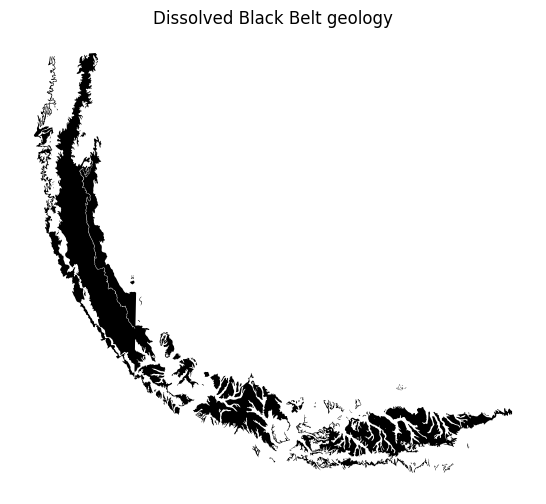

In [46]:
import geopandas as gpd
from shapely.ops import unary_union
import matplotlib.pyplot as plt

COMMON_CRS = "EPSG:5070"

black_belt = gpd.read_file("../data/processed/black_belt_al_ms.geojson").to_crs(COMMON_CRS)

black_belt_union = unary_union(black_belt.geometry)

black_belt_dissolved = gpd.GeoDataFrame(
    {"name": ["Black Belt geology"]},
    geometry=[black_belt_union],
    crs=COMMON_CRS,
)

fig, ax = plt.subplots(figsize=(10, 6))
black_belt_dissolved.plot(ax=ax, color="black")
ax.set_title("Dissolved Black Belt geology")
ax.set_axis_off()
plt.show()

In [47]:
black_belt_dissolved.to_file(
    "../data/processed/black_belt_al_ms_dissolved.geojson",
    driver="GeoJSON"
)

In [48]:
counties = gpd.read_file("../data/raw/census/cb_2018_us_county_20m.shp").to_crs(COMMON_CRS)

south_state_fips = {"01", "28"}  # Alabama, Mississippi
counties = counties[counties["STATEFP"].isin(south_state_fips)].copy()

belt_geom = black_belt_dissolved.geometry.iloc[0]

counties["centroid"] = counties.geometry.centroid
counties["intersects_black_belt"] = counties.geometry.intersects(belt_geom)
counties["centroid_in_black_belt"] = counties["centroid"].within(belt_geom)
counties["dist_to_black_belt_km"] = counties["centroid"].distance(belt_geom) / 1000.0

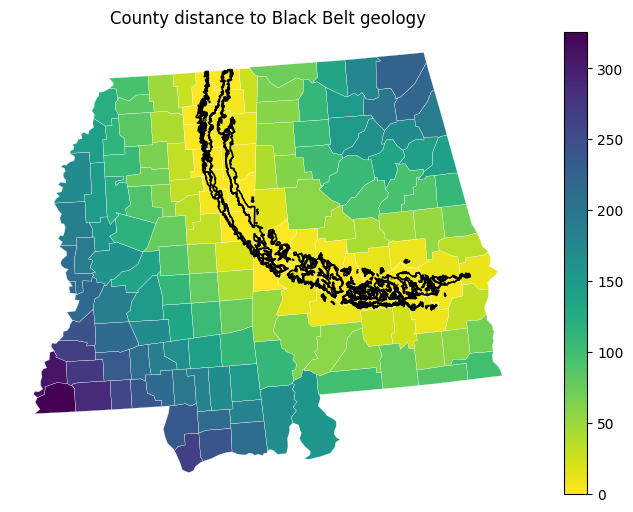

In [49]:
fig, ax = plt.subplots(figsize=(10, 6))

counties.plot(
    ax=ax,
    column="dist_to_black_belt_km",
    cmap="viridis_r",
    legend=True,
    edgecolor="none",
)

counties.boundary.plot(ax=ax, color="white", linewidth=0.15)
black_belt_dissolved.boundary.plot(ax=ax, color="black", linewidth=1.2)

ax.set_title("County distance to Black Belt geology")
ax.set_axis_off()
plt.show()

In [50]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [51]:
COMMON_CRS = "EPSG:5070"

COUNTIES_SHP = Path("../data/raw/census/cb_2018_us_county_20m.shp")
BLACK_BELT_DISSOLVED = Path("../data/processed/black_belt_al_ms_dissolved.geojson")
OUT = Path("../data/processed/counties_al_ms_black_belt_features.geojson")

In [52]:
counties = gpd.read_file(COUNTIES_SHP).to_crs(COMMON_CRS)
black_belt = gpd.read_file(BLACK_BELT_DISSOLVED).to_crs(COMMON_CRS)

In [53]:
state_fips = {"01", "28"}  # Alabama, Mississippi

counties = counties[counties["STATEFP"].isin(state_fips)].copy()

print(counties.shape)
counties[["STATEFP", "GEOID", "NAME"]].head()

(149, 10)


,STATEFP,GEOID,NAME
7,01,01043,Cullman
15,01,01059,Franklin
33,01,01023,Choctaw
57,01,01109,Pike
65,28,28115,Pontotoc


In [54]:
belt_geom = black_belt.geometry.iloc[0]

In [55]:
counties["centroid"] = counties.geometry.centroid

counties["intersects_black_belt"] = counties.geometry.intersects(belt_geom)
counties["centroid_in_black_belt"] = counties["centroid"].within(belt_geom)
counties["dist_to_black_belt_km"] = counties["centroid"].distance(belt_geom) / 1000.0

In [56]:
counties_features = counties[[
    "STATEFP",
    "COUNTYFP",
    "GEOID",
    "NAME",
    "geometry",
    "centroid",
    "intersects_black_belt",
    "centroid_in_black_belt",
    "dist_to_black_belt_km",
]].copy()

counties_features.head()

,STATEFP,COUNTYFP,GEOID,NAME,geometry,centroid,intersects_black_belt,centroid_in_black_belt,dist_to_black_belt_km
7,01,043,01043,Cullman,"POLYGON ((813867.623 1252211.812, 810853.035 1...",POINT (834568.777 1269660.475),False,False,150.007508
15,01,059,01059,Franklin,"POLYGON ((714262.312 1296237.428, 714559.688 1...",POINT (742801.372 1296358.28),False,False,59.493919
33,01,023,01023,Choctaw,"POLYGON ((708460.493 1008043.571, 708113.978 1...",POINT (726343.525 1023826.363),False,False,53.228702
57,01,109,01109,Pike,"POLYGON ((921175.012 1035624.607, 939484.833 1...",POINT (946468.853 1020101.055),True,False,9.467288
65,28,115,28115,Pontotoc,"POLYGON ((615737.072 1279269.531, 644629.625 1...",POINT (636099.866 1263562.148),True,False,2.409653


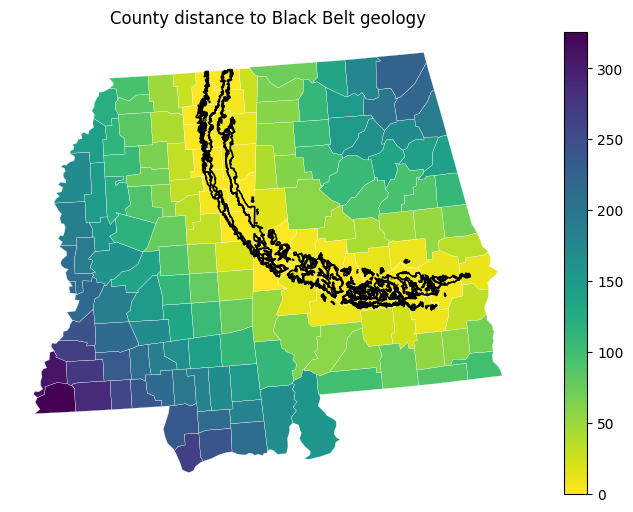

In [57]:
fig, ax = plt.subplots(figsize=(10, 6))

counties_features.plot(
    ax=ax,
    column="dist_to_black_belt_km",
    cmap="viridis_r",
    legend=True,
    edgecolor="none",
)

counties_features.boundary.plot(ax=ax, color="white", linewidth=0.15)
black_belt.boundary.plot(ax=ax, color="black", linewidth=1.2)

ax.set_title("County distance to Black Belt geology")
ax.set_axis_off()
plt.show()

In [58]:
counties_out = counties_features.copy()
counties_out["centroid_x"] = counties_out["centroid"].x
counties_out["centroid_y"] = counties_out["centroid"].y
counties_out = counties_out.drop(columns=["centroid"])

counties_out.to_file(OUT, driver="GeoJSON")

In [59]:
CSV_OUT = Path("../data/processed/counties_al_ms_black_belt_features.csv")

counties_out.drop(columns=["geometry"]).to_csv(CSV_OUT, index=False)